In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

m_tourney = pd.read_csv('MNCAATourneyCompactResults.csv')
w_tourney = pd.read_csv('WNCAATourneyCompactResults.csv')
m_seeds = pd.read_csv('MNCAATourneySeeds.csv')
w_seeds = pd.read_csv('WNCAATourneySeeds.csv')
m_regular = pd.read_csv('MRegularSeasonDetailedResults.csv')
w_regular = pd.read_csv('WRegularSeasonDetailedResults.csv')






In [4]:
def process_seeds(df):
    df['SeedNum'] = df['Seed'].apply(lambda x: int(x[1:3]))
    return df

m_seeds = process_seeds(m_seeds)
w_seeds = process_seeds(w_seeds)


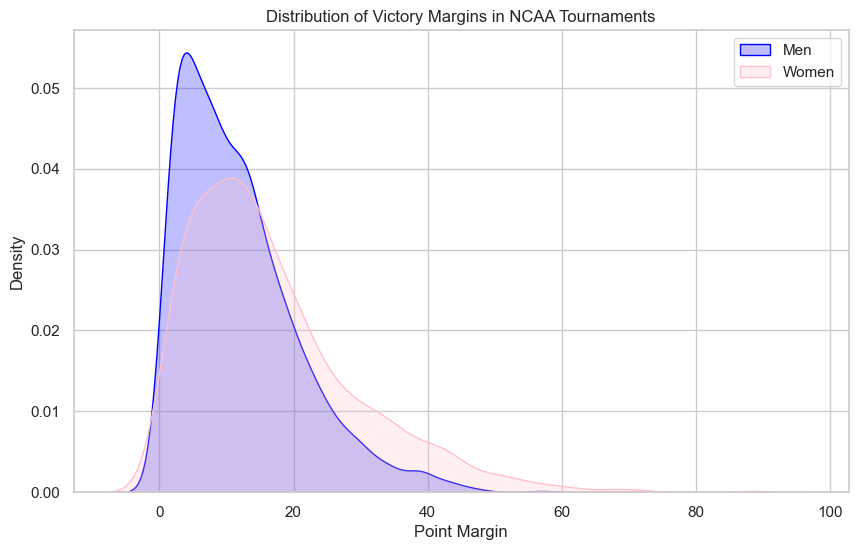

In [5]:
m_tourney['Margin'] = m_tourney['WScore'] - m_tourney['LScore']
w_tourney['Margin'] = w_tourney['WScore'] - w_tourney['LScore']

plt.figure(figsize=(10, 6))
sns.kdeplot(m_tourney['Margin'], label='Men', fill=True, color='blue')
sns.kdeplot(w_tourney['Margin'], label='Women', fill=True, color='pink')
plt.title('Distribution of Victory Margins in NCAA Tournaments')
plt.xlabel('Point Margin')
plt.legend()
plt.savefig('victory_margins.png')



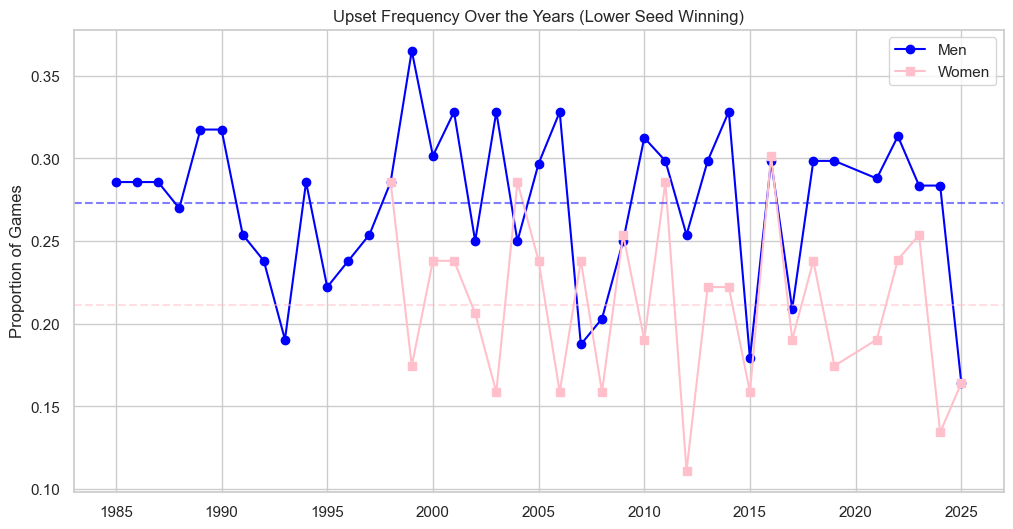

In [6]:
def get_upsets(tourney_df, seeds_df):
    win_seeds = seeds_df.rename(columns={'TeamID': 'WTeamID', 'SeedNum': 'WSeed'})
    loss_seeds = seeds_df.rename(columns={'TeamID': 'LTeamID', 'SeedNum': 'LSeed'})
    df = tourney_df.merge(win_seeds[['Season', 'WTeamID', 'WSeed']], on=['Season', 'WTeamID'])
    df = df.merge(loss_seeds[['Season', 'LTeamID', 'LSeed']], on=['Season', 'LTeamID'])
    df['is_upset'] = df['WSeed'] > df['LSeed']
    return df.groupby('Season')['is_upset'].mean()

m_upsets = get_upsets(m_tourney, m_seeds)
w_upsets = get_upsets(w_tourney, w_seeds)

plt.figure(figsize=(12, 6))
plt.plot(m_upsets.index, m_upsets.values, marker='o', label='Men', color='blue')
plt.plot(w_upsets.index, w_upsets.values, marker='s', label='Women', color='pink')
plt.axhline(m_upsets.mean(), color='blue', linestyle='--', alpha=0.5)
plt.axhline(w_upsets.mean(), color='pink', linestyle='--', alpha=0.5)
plt.title('Upset Frequency Over the Years (Lower Seed Winning)')
plt.ylabel('Proportion of Games')
plt.grid(True)
plt.legend()
plt.savefig('upset_trends.png')



In [7]:
def get_efficiency(df):
    df['WPoss'] = df['WFGA'] + 0.475 * df['WFTA'] - df['WOR'] + df['WTO']
    df['LPoss'] = df['LFGA'] + 0.475 * df['LFTA'] - df['LOR'] + df['LTO']
    
    w_off = df[['Season', 'WTeamID', 'WScore', 'WPoss']].rename(columns={'WTeamID': 'TeamID', 'WScore': 'Score', 'WPoss': 'Poss'})
    l_off = df[['Season', 'LTeamID', 'LScore', 'LPoss']].rename(columns={'LTeamID': 'TeamID', 'LScore': 'Score', 'LPoss': 'Poss'})
    off = pd.concat([w_off, l_off]).groupby(['Season', 'TeamID']).agg({'Score': 'sum', 'Poss': 'sum'})
    off['OffEff'] = 100 * off['Score'] / off['Poss']

    w_def = df[['Season', 'WTeamID', 'LScore', 'WPoss']].rename(columns={'WTeamID': 'TeamID', 'LScore': 'OppScore', 'WPoss': 'Poss'})
    l_def = df[['Season', 'LTeamID', 'WScore', 'LPoss']].rename(columns={'LTeamID': 'TeamID', 'WScore': 'OppScore', 'LPoss': 'Poss'})
    defens = pd.concat([w_def, l_def]).groupby(['Season', 'TeamID']).agg({'OppScore': 'sum', 'Poss': 'sum'})
    defens['DefEff'] = 100 * defens['OppScore'] / defens['Poss']
    
    return off.merge(defens[['DefEff']], on=['Season', 'TeamID']).reset_index()

C:\Users\matja\AppData\Local\Temp\ipykernel_54528\1194852236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WPoss'] = df['WFGA'] + 0.475 * df['WFTA'] - df['WOR'] + df['WTO']
C:\Users\matja\AppData\Local\Temp\ipykernel_54528\1194852236.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LPoss'] = df['LFGA'] + 0.475 * df['LFTA'] - df['LOR'] + df['LTO']


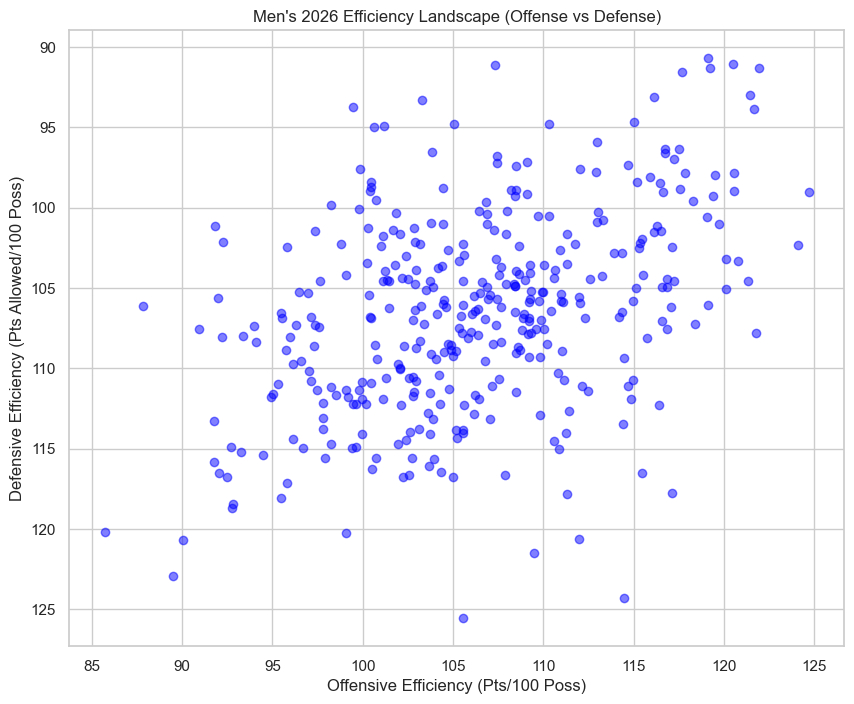

In [8]:
m_eff_2026 = get_efficiency(m_regular[m_regular['Season'] == 2026])

plt.figure(figsize=(10, 8))
plt.scatter(m_eff_2026['OffEff'], m_eff_2026['DefEff'], alpha=0.5, color='blue')
plt.gca().invert_yaxis() 
plt.title('Men\'s 2026 Efficiency Landscape (Offense vs Defense)')
plt.xlabel('Offensive Efficiency (Pts/100 Poss)')
plt.ylabel('Defensive Efficiency (Pts Allowed/100 Poss)')
plt.grid(True)

In [10]:

def compute_four_factors(df):
    df['Poss'] = df['FGA'] + 0.475 * df['FTA'] - df['OR'] + df['TO']
    df['eFG'] = (df['FGM'] + 0.5 * df['FGM3']) / df['FGA']
    df['TO_rate'] = df['TO'] / df['Poss']
    df['OR_rate'] = df['OR'] / (df['OR'] + df['Opp_DR'])
    df['FT_rate'] = df['FTM'] / df['FGA']
    return df



In [11]:
def get_team_season_stats(detailed_df):
    w_stats = detailed_df[['Season', 'WTeamID', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WTO', 'LDR', 'WScore', 'LScore']].copy()
    w_stats.columns = ['Season', 'TeamID', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'TO', 'Opp_DR', 'Score', 'OppScore']
    
    l_stats = detailed_df[['Season', 'LTeamID', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LTO', 'WDR', 'LScore', 'WScore']].copy()
    l_stats.columns = ['Season', 'TeamID', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'TO', 'Opp_DR', 'Score', 'OppScore']
    
    combined = pd.concat([w_stats, l_stats])
    
    combined = compute_four_factors(combined)
    
    stats = combined.groupby(['Season', 'TeamID']).agg({
        'eFG': 'mean',
        'TO_rate': 'mean',
        'OR_rate': 'mean',
        'FT_rate': 'mean',
        'Score': 'mean',
        'OppScore': 'mean'
    }).reset_index()
    
    stats['NetRating'] = stats['Score'] - stats['OppScore']
    return stats



In [12]:

m_stats = get_team_season_stats(m_regular)
w_stats = get_team_season_stats(w_regular)

def prepare_plot_data(tourney_df, stats_df, seeds_df):
    df = tourney_df.merge(seeds_df[['Season', 'TeamID', 'SeedNum']], left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedNum': 'WSeed'}).drop('TeamID', axis=1)
    df = df.merge(seeds_df[['Season', 'TeamID', 'SeedNum']], left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedNum': 'LSeed'}).drop('TeamID', axis=1)
    
    df = df.merge(stats_df, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={c: 'W_'+c for c in stats_df.columns if c not in ['Season', 'TeamID']}).drop('TeamID', axis=1)
    df = df.merge(stats_df, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={c: 'L_'+c for c in stats_df.columns if c not in ['Season', 'TeamID']}).drop('TeamID', axis=1)
    return df

m_plot_data = prepare_plot_data(m_tourney, m_stats, m_seeds)
w_plot_data = prepare_plot_data(w_tourney, w_stats, w_seeds)


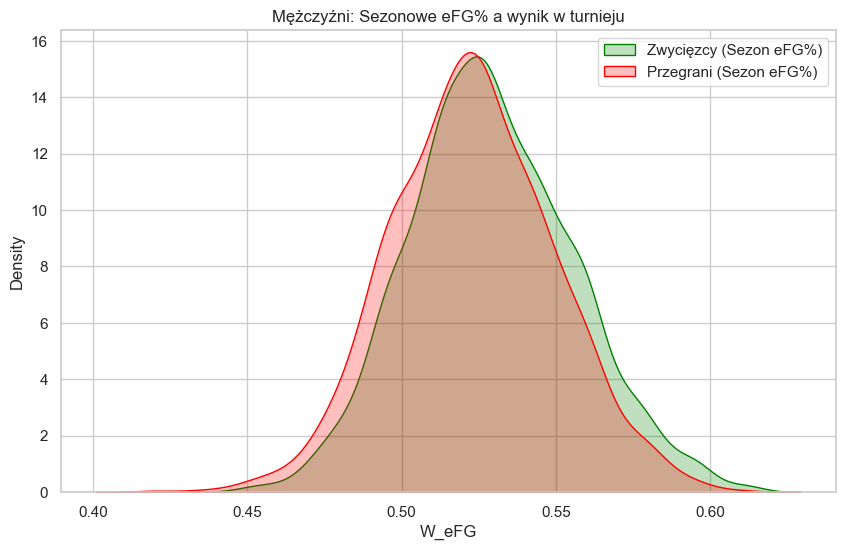

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(m_plot_data['W_eFG'], label='Zwycięzcy (Sezon eFG%)', fill=True, color='green')
sns.kdeplot(m_plot_data['L_eFG'], label='Przegrani (Sezon eFG%)', fill=True, color='red')
plt.title('Mężczyźni: Sezonowe eFG% a wynik w turnieju')
plt.legend()
plt.savefig('men_efg_dist.png')



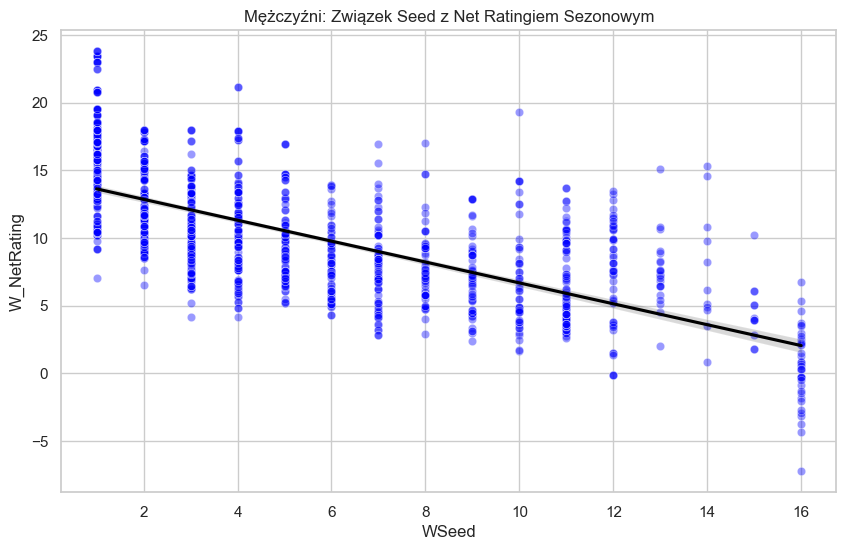

In [14]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=m_plot_data, x='WSeed', y='W_NetRating', alpha=0.4, color='blue')
sns.regplot(data=m_plot_data, x='WSeed', y='W_NetRating', scatter=False, color='black')
plt.title('Mężczyźni: Związek Seed z Net Ratingiem Sezonowym')
plt.savefig('men_seed_netrating.png')



C:\Users\matja\AppData\Local\Temp\ipykernel_54528\3487911981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=m_plot_data, x='WSeed', y='W_TO_rate', palette='coolwarm')


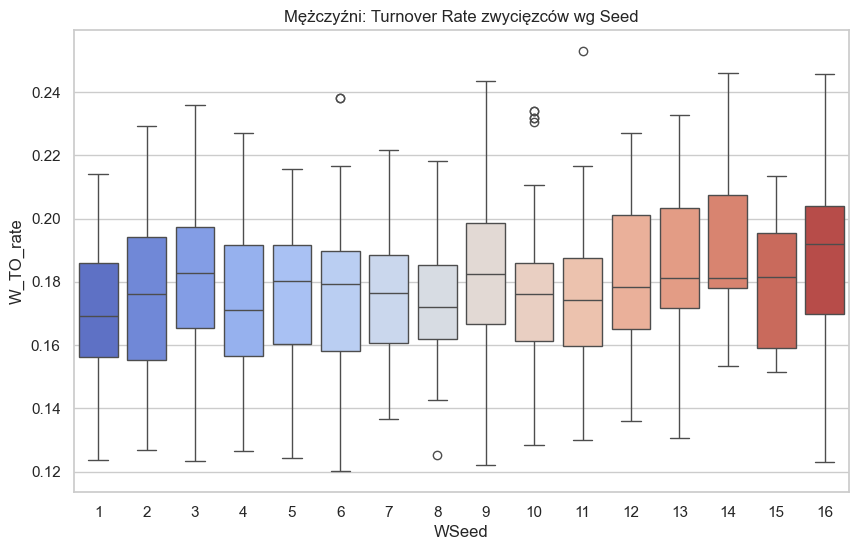

In [15]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=m_plot_data, x='WSeed', y='W_TO_rate', palette='coolwarm')
plt.title('Mężczyźni: Turnover Rate zwycięzców wg Seed')
plt.savefig('men_turnover_box.png')



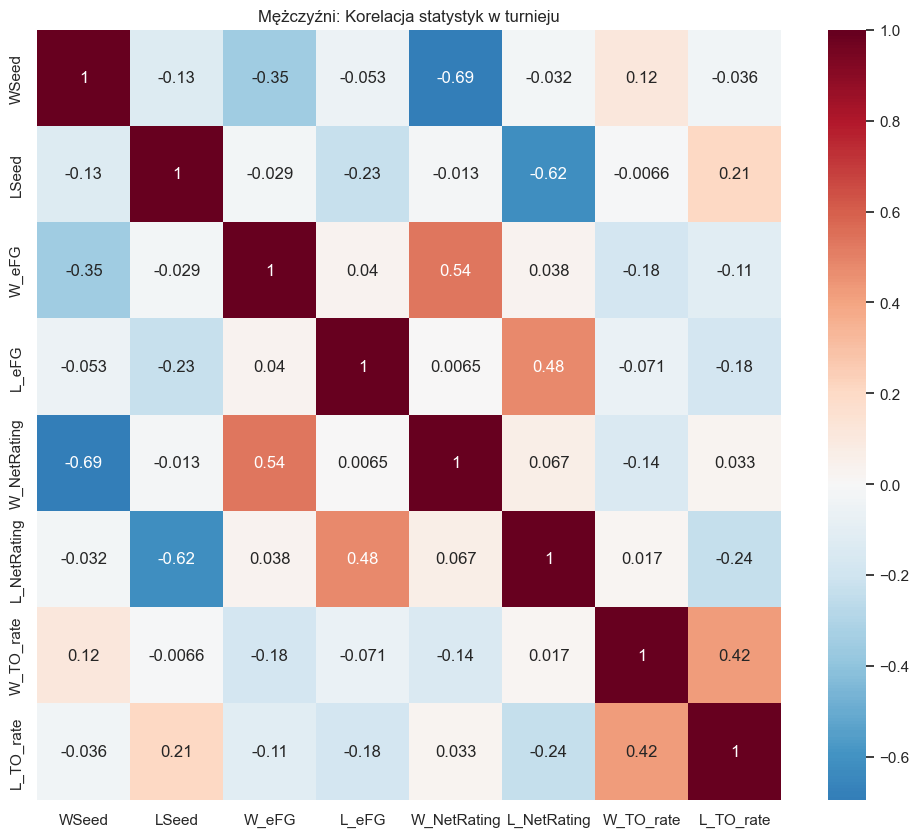

In [16]:
plt.figure(figsize=(12, 10))
cols = ['WSeed', 'LSeed', 'W_eFG', 'L_eFG', 'W_NetRating', 'L_NetRating', 'W_TO_rate', 'L_TO_rate']
sns.heatmap(m_plot_data[cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Mężczyźni: Korelacja statystyk w turnieju')
plt.savefig('men_correlation_heatmap.png')